In [1]:
# 古诗数据预处理：读取与基本统计

# 读取 poetry_clean_brief.txt
file_path = "../poetry_clean_brief.txt"

with open(file_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

# 去除每行末尾的换行符
lines = [line.rstrip("\n") for line in lines]

print(f"总行数（诗歌数量）: {len(lines)}")
print(f"前 3 行示例:")
for i, line in enumerate(lines[:3]):
    print(f"  [{i+1}] {line[:60]}...")


总行数（诗歌数量）: 3000
前 3 行示例:
  [1] 西陆蝉声唱，南冠客思侵。那堪玄鬓影，来对白头吟。露重飞难进，风多响易沈。无人信高洁，谁为表予心。...
  [2] 夫子何为者？栖栖一代中。地犹鄹氏邑，宅即鲁王宫。叹凤嗟身否，伤麟怨道穷。今看两楹奠，当与梦时同。...
  [3] 秦时明月汉时关，万里长征人未还。但使龙城飞将在，不教胡马度阴山。...


In [2]:
# 统计基本信息

# 将所有诗句拼接为一个字符串
full_text = "\n".join(lines)

# 总字符数（含换行符）
total_chars_with_newlines = len(full_text)

# 总字符数（不含换行符，仅诗歌内容）
total_chars_poem_only = sum(len(line) for line in lines)

# 词表：所有出现过的不同字符
vocab_chars = sorted(set(full_text))  # 包含换行符

print(f"总字符数（含换行）: {total_chars_with_newlines:,}")
print(f"总字符数（纯诗歌）: {total_chars_poem_only:,}")
print(f"词表大小（不同字符数，含换行符）: {len(vocab_chars)}")
print(f"\n词表前 30 个字符: {vocab_chars[:30]}")
print(f"词表后 30 个字符: {vocab_chars[-30:]}")


总字符数（含换行）: 140,713
总字符数（纯诗歌）: 137,714
词表大小（不同字符数，含换行符）: 4042

词表前 30 个字符: ['\n', '。', '一', '丁', '七', '万', '丈', '三', '上', '下', '不', '与', '丑', '专', '且', '丕', '世', '丘', '业', '丛', '东', '丝', '丞', '两', '严', '丧', '个', '中', '丰', '丱']
词表后 30 个字符: ['黎', '黏', '黑', '黔', '默', '黛', '黠', '黯', '黻', '黼', '鼋', '鼍', '鼎', '鼓', '鼙', '鼠', '鼯', '鼹', '鼻', '齅', '齐', '齑', '齿', '龄', '龙', '龚', '龛', '龟', '，', '？']


In [3]:
# 【必做】字符级构建词表

# 获取所有不重复字符（仅诗歌内容，不含换行符，按需可含）
chars_only_text = "".join(lines)  # 仅诗歌文字，无换行
vocab = sorted(set(chars_only_text))

# 词表大小
vocab_size = len(vocab)  # 6122
print(f"字符级词表大小: {vocab_size}")

# 构建映射表
# char -> idx（从 1 开始，0 保留给 <PAD>）
char2idx = {ch: i + 1 for i, ch in enumerate(vocab)}

# idx -> char
idx2char = {i + 1: ch for i, ch in enumerate(vocab)}

# 常用特殊 token
char2idx["<PAD>"] = 0       # 填充
char2idx["<UNK>"] = vocab_size + 1  # 未知字符
char2idx["<BOS>"] = vocab_size + 2  # 句子开头（可选）
char2idx["<EOS>"] = vocab_size + 3  # 句子结尾（可选）

idx2char[0] = "<PAD>"
idx2char[vocab_size + 1] = "<UNK>"
idx2char[vocab_size + 2] = "<BOS>"
idx2char[vocab_size + 3] = "<EOS>"

print(f"词表总大小（含特殊 token）: {len(char2idx)}")
print(f"\n—— 字符映射示例 ——")
for i, (ch, idx) in enumerate(char2idx.items()):
    if i < 15 or i >= len(char2idx) - 5:
        print(f"  '{ch}' -> {idx}", end="")
        if i == 14:
            print(f"\n  ... 省略 {len(char2idx) - 20} 个 ...")

# 展示一条诗的编码示例
sample_poem = lines[2] # 第三首诗
encoded = [char2idx.get(ch, char2idx["<UNK>"]) for ch in sample_poem]
print(f"\n—— 编码示例 ——")
print(f"原文: {sample_poem}")
print(f"编码: {encoded}")


字符级词表大小: 4041
词表总大小（含特殊 token）: 4045

—— 字符映射示例 ——
  '。' -> 1  '一' -> 2  '丁' -> 3  '七' -> 4  '万' -> 5  '丈' -> 6  '三' -> 7  '上' -> 8  '下' -> 9  '不' -> 10  '与' -> 11  '丑' -> 12  '专' -> 13  '且' -> 14  '丕' -> 15
  ... 省略 4025 个 ...
  '？' -> 4041  '<PAD>' -> 0  '<UNK>' -> 4042  '<BOS>' -> 4043  '<EOS>' -> 4044
—— 编码示例 ——
原文: 秦时明月汉时关，万里长征人未还。但使龙城飞将在，不教胡马度阴山。
编码: [2443, 1454, 1463, 1528, 1799, 1454, 247, 4040, 5, 3572, 3642, 1071, 86, 1540, 3439, 1, 137, 154, 4036, 632, 3833, 845, 600, 4040, 10, 1394, 2788, 3863, 1016, 3683, 881, 1]


In [4]:
# 将所有诗歌编码为 token ID 序列，每首诗末尾添加 <EOS>

eos_id = char2idx["<EOS>"]

all_ids = []
for line in lines:
    ids = [char2idx.get(ch, char2idx["<UNK>"]) for ch in line]
    all_ids.extend(ids)
    all_ids.append(eos_id)  # 每首诗结尾加 <EOS>

print(f"编码后总 token 数: {len(all_ids):,}")
print(f"前 50 个 token: {all_ids[:50]}")
print(f"解码验证: {''.join(idx2char.get(i, '<UNK>') for i in all_ids[:50])}")


编码后总 token 数: 140,714
前 50 个 token: [3173, 3692, 3090, 667, 535, 4040, 399, 269, 807, 1115, 167, 1, 3511, 646, 2167, 3920, 1066, 4040, 1565, 839, 2289, 687, 482, 1, 3769, 3573, 3833, 3729, 3441, 4040, 3824, 678, 521, 1465, 1818, 1, 1443, 86, 178, 3912, 1864, 4040, 3249, 34, 3126, 62, 1091, 1, 4044, 683]
解码验证: 西陆蝉声唱，南冠客思侵。那堪玄鬓影，来对白头吟。露重飞难进，风多响易沈。无人信高洁，谁为表予心。<EOS>夫


In [5]:
# 滑动窗口切割序列，构造 (input_ids, target_ids) 样本对

import torch
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np

SEQ_LEN = 64       # 序列长度
STRIDE = 32        # 滑动步长（< seq_len 则样本有重叠）

# 将 token 列表转为 tensor
all_tokens = torch.tensor(all_ids, dtype=torch.long)

# 滑动窗口生成 input/target 对
# input:  [i, i+SEQ_LEN)     → 模型输入
# target: [i+1, i+SEQ_LEN+1) → 每个位置预测下一个字符
inputs_list = []
targets_list = []

for start in range(0, len(all_tokens) - SEQ_LEN - 1, STRIDE):
    inp = all_tokens[start : start + SEQ_LEN]
    tgt = all_tokens[start + 1 : start + SEQ_LEN + 1]
    inputs_list.append(inp)
    targets_list.append(tgt)

inputs = torch.stack(inputs_list)     # (num_samples, SEQ_LEN)
targets = torch.stack(targets_list)   # (num_samples, SEQ_LEN)

print(f"序列长度: {SEQ_LEN}，滑动步长: {STRIDE}")
print(f"样本总数: {len(inputs):,}")
print(f"inputs  形状: {inputs.shape}")
print(f"targets 形状: {targets.shape}")
print(f"\n—— 第 0 条样本 ——")
print(f"input : {inputs[0].tolist()}")
print(f"target: {targets[0].tolist()}")
print(f"\ninput  解码: {repr(''.join(idx2char[i.item()] for i in inputs[0]))}")
print(f"target 解码: {repr(''.join(idx2char[i.item()] for i in targets[0]))}")

序列长度: 64，滑动步长: 32
样本总数: 4,396
inputs  形状: torch.Size([4396, 64])
targets 形状: torch.Size([4396, 64])

—— 第 0 条样本 ——
input : [3173, 3692, 3090, 667, 535, 4040, 399, 269, 807, 1115, 167, 1, 3511, 646, 2167, 3920, 1066, 4040, 1565, 839, 2289, 687, 482, 1, 3769, 3573, 3833, 3729, 3441, 4040, 3824, 678, 521, 1465, 1818, 1, 1443, 86, 178, 3912, 1864, 4040, 3249, 34, 3126, 62, 1091, 1, 4044, 683, 770, 143, 34, 2745, 4041, 1626, 1626, 2, 105, 27, 1, 602, 2139, 3540]
target: [3692, 3090, 667, 535, 4040, 399, 269, 807, 1115, 167, 1, 3511, 646, 2167, 3920, 1066, 4040, 1565, 839, 2289, 687, 482, 1, 3769, 3573, 3833, 3729, 3441, 4040, 3824, 678, 521, 1465, 1818, 1, 1443, 86, 178, 3912, 1864, 4040, 3249, 34, 3126, 62, 1091, 1, 4044, 683, 770, 143, 34, 2745, 4041, 1626, 1626, 2, 105, 27, 1, 602, 2139, 3540, 1785]

input  解码: '西陆蝉声唱，南冠客思侵。那堪玄鬓影，来对白头吟。露重飞难进，风多响易沈。无人信高洁，谁为表予心。<EOS>夫子何为者？栖栖一代中。地犹鄹'
target 解码: '陆蝉声唱，南冠客思侵。那堪玄鬓影，来对白头吟。露重飞难进，风多响易沈。无人信高洁，谁为表予心。<EOS>夫子何为者？栖栖一代中。地犹鄹氏'


In [6]:
# 划分训练集/测试集，封装 PyTorch Dataset 与 DataLoader

# ==================== 自定义 Dataset ====================
class PoetryDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = inputs
        self.targets = targets

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

# ==================== 划分训练集与测试集 ====================
TEST_RATIO = 0.1
test_size = int(len(inputs) * TEST_RATIO)
train_size = len(inputs) - test_size

# 固定随机种子保证可复现
generator = torch.Generator().manual_seed(42)
train_dataset, test_dataset = random_split(
    PoetryDataset(inputs, targets),
    [train_size, test_size],
    generator=generator
)

print(f"训练集样本数: {train_size:,}")
print(f"测试集样本数: {test_size:,}")
print(f"测试集比例: {test_size / len(inputs) * 100:.1f}%")

# ==================== 封装 DataLoader ====================
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,           # 训练时打乱
    drop_last=True,         # 丢弃最后不足一个 batch 的部分
    num_workers=0           # Windows 下建议设为 0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,          # 测试时不打乱
    drop_last=False,
    num_workers=0
)

print(f"\nBatch size: {BATCH_SIZE}")
print(f"训练 DataLoader 批次数: {len(train_loader)}")
print(f"测试 DataLoader 批次数: {len(test_loader)}")

# ==================== 验证一个 batch ====================
for batch_inputs, batch_targets in train_loader:
    print(f"\n—— 一个 batch 的形状 ——")
    print(f"batch_inputs:  {batch_inputs.shape}   # (batch_size={BATCH_SIZE}, seq_len={SEQ_LEN})")
    print(f"batch_targets: {batch_targets.shape}  # (batch_size={BATCH_SIZE}, seq_len={SEQ_LEN})")
    print(f"\n该 batch 第 0 条 input:  {batch_inputs[0][:20].tolist()}...")
    print(f"该 batch 第 0 条 target: {batch_targets[0][:20].tolist()}...")
    break

print(f"\n[OK] 数据预处理完成：{len(train_loader)} 个训练 batch，{len(test_loader)} 个测试 batch")


训练集样本数: 3,957
测试集样本数: 439
测试集比例: 10.0%

Batch size: 128
训练 DataLoader 批次数: 30
测试 DataLoader 批次数: 4

—— 一个 batch 的形状 ——
batch_inputs:  torch.Size([128, 64])   # (batch_size=128, seq_len=64)
batch_targets: torch.Size([128, 64])  # (batch_size=128, seq_len=64)

该 batch 第 0 条 input:  [2673, 42, 1542, 1565, 226, 10, 3222, 4040, 1844, 2170, 503, 42, 709, 2461, 4008, 1, 1, 4044, 584, 468]...
该 batch 第 0 条 target: [42, 1542, 1565, 226, 10, 3222, 4040, 1844, 2170, 503, 42, 709, 2461, 4008, 1, 1, 4044, 584, 468, 388]...

[OK] 数据预处理完成：30 个训练 batch，4 个测试 batch


In [7]:
# ==================== 模型定义 ====================
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F

# 设备选择
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 模型超参数
VOCAB_SIZE = len(char2idx)   # 6126（含特殊 token）
EMBED_DIM = 128              # 嵌入维度
HIDDEN_SIZE = 128            # 隐藏层大小（>= 128）
NUM_LAYERS = 1               # RNN 层数


class CharRNN(nn.Module):
    """Baseline：简单 RNN 语言模型"""
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers=1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)  # <PAD>=0
        self.rnn = nn.RNN(embed_dim, hidden_size, num_layers,
                          batch_first=True, dropout=0.0)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        # x: (batch, seq_len)
        emb = self.embed(x)                       # (B, S, E)
        out, hidden = self.rnn(emb, hidden)       # (B, S, H)
        logits = self.fc(out)                     # (B, S, V)
        return logits, hidden


class CharLSTM(nn.Module):
    """核心模型：LSTM 语言模型"""
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers=1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_size, num_layers,
                            batch_first=True, dropout=0.0)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.embed(x)                       # (B, S, E)
        out, hidden = self.lstm(emb, hidden)      # (B, S, H)
        logits = self.fc(out)                     # (B, S, V)
        return logits, hidden


# 实例化两个模型
model_rnn = CharRNN(VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, NUM_LAYERS).to(device)
model_lstm = CharLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, NUM_LAYERS).to(device)

# 统计参数量
def count_params(model, name):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name}: 总参数 {total:,}，可训练 {trainable:,}")

count_params(model_rnn, "CharRNN")
count_params(model_lstm, "CharLSTM")
print(f"\n词表大小: {VOCAB_SIZE}，嵌入维度: {EMBED_DIM}，隐藏层: {HIDDEN_SIZE}")


使用设备: cpu
CharRNN: 总参数 1,072,589，可训练 1,072,589
CharLSTM: 总参数 1,171,661，可训练 1,171,661

词表大小: 4045，嵌入维度: 128，隐藏层: 128


In [8]:
# ==================== LSTM 变体：GRU + 双层 LSTM ====================

class CharGRU(nn.Module):
    """变体1：GRU 语言模型 —— 比 LSTM 少一个门，参数更少，训练更快"""
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers=1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_size, num_layers,
                          batch_first=True, dropout=0.0)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.embed(x)
        out, hidden = self.gru(emb, hidden)
        logits = self.fc(out)
        return logits, hidden


class CharLSTM2Layer(nn.Module):
    """变体2：双层 LSTM —— 更深的网络，更强的序列建模能力"""
    def __init__(self, vocab_size, embed_dim, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_size, num_layers=2,
                            batch_first=True, dropout=0.3)  # 层间加 dropout 防过拟合
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.embed(x)
        out, hidden = self.lstm(emb, hidden)
        logits = self.fc(out)
        return logits, hidden


# 实例化两个变体
model_gru = CharGRU(VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, num_layers=1).to(device)
model_lstm2 = CharLSTM2Layer(VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE).to(device)

count_params(model_gru, "CharGRU (单层)")
count_params(model_lstm2, "CharLSTM (双层)")

print("\n变体对照表:")
print(f"  {'模型':<20} {'结构':<15} {'参数量':<12} {'特点'}")
print(f"  {'-'*60}")
print(f"  {'CharRNN':<20} {'RNN 1层':<15} {'1,607,406':<12} {'Baseline，无门控'}")
print(f"  {'CharLSTM':<20} {'LSTM 1层':<15} {'1,706,478':<12} {'核心模型，3门控'}")
print(f"  {'CharGRU':<20} {'GRU 1层':<15} {f'{sum(p.numel() for p in model_gru.parameters()):,}':<12} {'2门控，参数最少'}")
print(f"  {'CharLSTM2Layer':<20} {'LSTM 2层':<15} {f'{sum(p.numel() for p in model_lstm2.parameters()):,}':<12} {'更深，层间Dropout'}")


CharGRU (单层): 总参数 1,138,637，可训练 1,138,637
CharLSTM (双层): 总参数 1,303,757，可训练 1,303,757

变体对照表:
  模型                   结构              参数量          特点
  ------------------------------------------------------------
  CharRNN              RNN 1层          1,607,406    Baseline，无门控
  CharLSTM             LSTM 1层         1,706,478    核心模型，3门控
  CharGRU              GRU 1层          1,138,637    2门控，参数最少
  CharLSTM2Layer       LSTM 2层         1,303,757    更深，层间Dropout


In [9]:
# ==================== 训练配置与训练函数 ====================

# 损失函数：交叉熵 —— 语言建模的标准选择
# 原因：本质是对每个位置做 vocab_size 类分类，CE 直接度量预测分布与真实标签的 KL 散度
criterion = nn.CrossEntropyLoss(ignore_index=char2idx["<PAD>"])  # 忽略 <PAD> 位置

# 优化器：Adam —— 自适应学习率，对 RNN 梯度尺度不稳定问题鲁棒
LEARNING_RATE = 0.001

optimizer_rnn = optim.Adam(model_rnn.parameters(), lr=LEARNING_RATE)
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=LEARNING_RATE)

NUM_EPOCHS = 20


def train_one_epoch(model, loader, optimizer, criterion, device, model_name=""):
    """训练一个 epoch，返回平均 loss"""
    model.train()
    total_loss = 0.0
    total_tokens = 0

    for batch_idx, (batch_inputs, batch_targets) in enumerate(loader):
        batch_inputs = batch_inputs.to(device)      # (B, S)
        batch_targets = batch_targets.to(device)     # (B, S)

        optimizer.zero_grad()

        # 前向传播
        logits, _ = model(batch_inputs)              # (B, S, V)
        # 重塑为分类格式：(B*S, V) vs (B*S)
        loss = criterion(
            logits.view(-1, logits.size(-1)),        # (B*S, V)
            batch_targets.view(-1)                    # (B*S)
        )

        # 反向传播
        loss.backward()
        # 梯度裁剪，防止 RNN 梯度爆炸
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * batch_inputs.size(0)
        total_tokens += (batch_targets != char2idx["<PAD>"]).sum().item()

    avg_loss = total_loss / total_tokens
    return avg_loss


def evaluate(model, loader, criterion, device):
    """在测试集上评估，返回平均 loss"""
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for batch_inputs, batch_targets in loader:
            batch_inputs = batch_inputs.to(device)
            batch_targets = batch_targets.to(device)

            logits, _ = model(batch_inputs)
            loss = criterion(
                logits.view(-1, logits.size(-1)),
                batch_targets.view(-1)
            )

            total_loss += loss.item() * batch_inputs.size(0)
            total_tokens += (batch_targets != char2idx["<PAD>"]).sum().item()

    avg_loss = total_loss / total_tokens
    return avg_loss


print("训练配置:")
print(f"  损失函数: CrossEntropyLoss (ignore_index=<PAD>)")
print(f"  优化器: Adam, lr={LEARNING_RATE}")
print(f"  梯度裁剪: max_norm=1.0")
print(f"  训练轮数: {NUM_EPOCHS}")
print(f"  训练 batch 数: {len(train_loader)}，测试 batch 数: {len(test_loader)}")


训练配置:
  损失函数: CrossEntropyLoss (ignore_index=<PAD>)
  优化器: Adam, lr=0.001
  梯度裁剪: max_norm=1.0
  训练轮数: 20
  训练 batch 数: 30，测试 batch 数: 4


In [10]:
# ==================== 训练两个模型 ====================

import time

history = {"rnn": {"train": [], "test": []}, "lstm": {"train": [], "test": []}}

print("=" * 60)
print("训练 CharRNN (Baseline)")
print("=" * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    train_loss = train_one_epoch(model_rnn, train_loader, optimizer_rnn, criterion, device)
    test_loss = evaluate(model_rnn, test_loader, criterion, device)

    history["rnn"]["train"].append(train_loss)
    history["rnn"]["test"].append(test_loss)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"train_loss: {train_loss:.4f} | test_loss: {test_loss:.4f} | "
          f"time: {elapsed:.1f}s")

print(f"\nRNN 最终: train_loss={history['rnn']['train'][-1]:.4f}, "
      f"test_loss={history['rnn']['test'][-1]:.4f}")

print("\n" + "=" * 60)
print("训练 CharLSTM (核心模型)")
print("=" * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    train_loss = train_one_epoch(model_lstm, train_loader, optimizer_lstm, criterion, device)
    test_loss = evaluate(model_lstm, test_loader, criterion, device)

    history["lstm"]["train"].append(train_loss)
    history["lstm"]["test"].append(test_loss)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"train_loss: {train_loss:.4f} | test_loss: {test_loss:.4f} | "
          f"time: {elapsed:.1f}s")

print(f"\nLSTM 最终: train_loss={history['lstm']['train'][-1]:.4f}, "
      f"test_loss={history['lstm']['test'][-1]:.4f}")

print("\n[OK] 两个模型训练完成！")


训练 CharRNN (Baseline)
Epoch  1/20 | train_loss: 0.1177 | test_loss: 0.1026 | time: 5.1s
Epoch  2/20 | train_loss: 0.1010 | test_loss: 0.1008 | time: 5.1s
Epoch  3/20 | train_loss: 0.0994 | test_loss: 0.0991 | time: 5.2s
Epoch  4/20 | train_loss: 0.0975 | test_loss: 0.0974 | time: 5.1s
Epoch  5/20 | train_loss: 0.0957 | test_loss: 0.0960 | time: 5.0s
Epoch  6/20 | train_loss: 0.0943 | test_loss: 0.0948 | time: 5.0s
Epoch  7/20 | train_loss: 0.0929 | test_loss: 0.0936 | time: 5.2s
Epoch  8/20 | train_loss: 0.0913 | test_loss: 0.0923 | time: 5.2s
Epoch  9/20 | train_loss: 0.0897 | test_loss: 0.0910 | time: 5.0s
Epoch 10/20 | train_loss: 0.0882 | test_loss: 0.0898 | time: 5.1s
Epoch 11/20 | train_loss: 0.0868 | test_loss: 0.0888 | time: 5.1s
Epoch 12/20 | train_loss: 0.0855 | test_loss: 0.0878 | time: 5.3s
Epoch 13/20 | train_loss: 0.0842 | test_loss: 0.0869 | time: 5.3s
Epoch 14/20 | train_loss: 0.0831 | test_loss: 0.0860 | time: 5.1s
Epoch 15/20 | train_loss: 0.0819 | test_loss: 0.0852 |

In [11]:
# ==================== 训练两个变体模型 ====================

# 为变体模型创建优化器（LEARNING_RATE 已在 Cell 9 中定义）
optimizer_gru = optim.Adam(model_gru.parameters(), lr=LEARNING_RATE)
optimizer_lstm2 = optim.Adam(model_lstm2.parameters(), lr=LEARNING_RATE)

# 扩展 history 字典
history["gru"] = {"train": [], "test": []}
history["lstm2"] = {"train": [], "test": []}

print("=" * 60)
print("训练 CharGRU (变体1: LSTM -> GRU)")
print("=" * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    train_loss = train_one_epoch(model_gru, train_loader, optimizer_gru, criterion, device)
    test_loss = evaluate(model_gru, test_loader, criterion, device)

    history["gru"]["train"].append(train_loss)
    history["gru"]["test"].append(test_loss)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"train_loss: {train_loss:.4f} | test_loss: {test_loss:.4f} | "
          f"time: {elapsed:.1f}s")

print(f"\nGRU 最终: train_loss={history['gru']['train'][-1]:.4f}, "
      f"test_loss={history['gru']['test'][-1]:.4f}")

print("\n" + "=" * 60)
print("训练 CharLSTM2Layer (变体2: 单层 -> 双层 LSTM)")
print("=" * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    train_loss = train_one_epoch(model_lstm2, train_loader, optimizer_lstm2, criterion, device)
    test_loss = evaluate(model_lstm2, test_loader, criterion, device)

    history["lstm2"]["train"].append(train_loss)
    history["lstm2"]["test"].append(test_loss)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"train_loss: {train_loss:.4f} | test_loss: {test_loss:.4f} | "
          f"time: {elapsed:.1f}s")

print(f"\nLSTM2 最终: train_loss={history['lstm2']['train'][-1]:.4f}, "
      f"test_loss={history['lstm2']['test'][-1]:.4f}")

print("\n[OK] 两个变体模型训练完成！")


训练 CharGRU (变体1: LSTM -> GRU)
Epoch  1/20 | train_loss: 0.1176 | test_loss: 0.1029 | time: 6.2s
Epoch  2/20 | train_loss: 0.1013 | test_loss: 0.1007 | time: 6.2s
Epoch  3/20 | train_loss: 0.0991 | test_loss: 0.0987 | time: 6.1s
Epoch  4/20 | train_loss: 0.0973 | test_loss: 0.0972 | time: 6.1s
Epoch  5/20 | train_loss: 0.0958 | test_loss: 0.0960 | time: 6.1s
Epoch  6/20 | train_loss: 0.0945 | test_loss: 0.0950 | time: 6.1s
Epoch  7/20 | train_loss: 0.0935 | test_loss: 0.0942 | time: 6.2s
Epoch  8/20 | train_loss: 0.0924 | test_loss: 0.0933 | time: 6.2s
Epoch  9/20 | train_loss: 0.0913 | test_loss: 0.0924 | time: 6.1s
Epoch 10/20 | train_loss: 0.0902 | test_loss: 0.0916 | time: 6.1s
Epoch 11/20 | train_loss: 0.0890 | test_loss: 0.0906 | time: 6.2s
Epoch 12/20 | train_loss: 0.0878 | test_loss: 0.0897 | time: 6.2s
Epoch 13/20 | train_loss: 0.0867 | test_loss: 0.0888 | time: 6.1s
Epoch 14/20 | train_loss: 0.0855 | test_loss: 0.0880 | time: 6.0s
Epoch 15/20 | train_loss: 0.0844 | test_loss: 

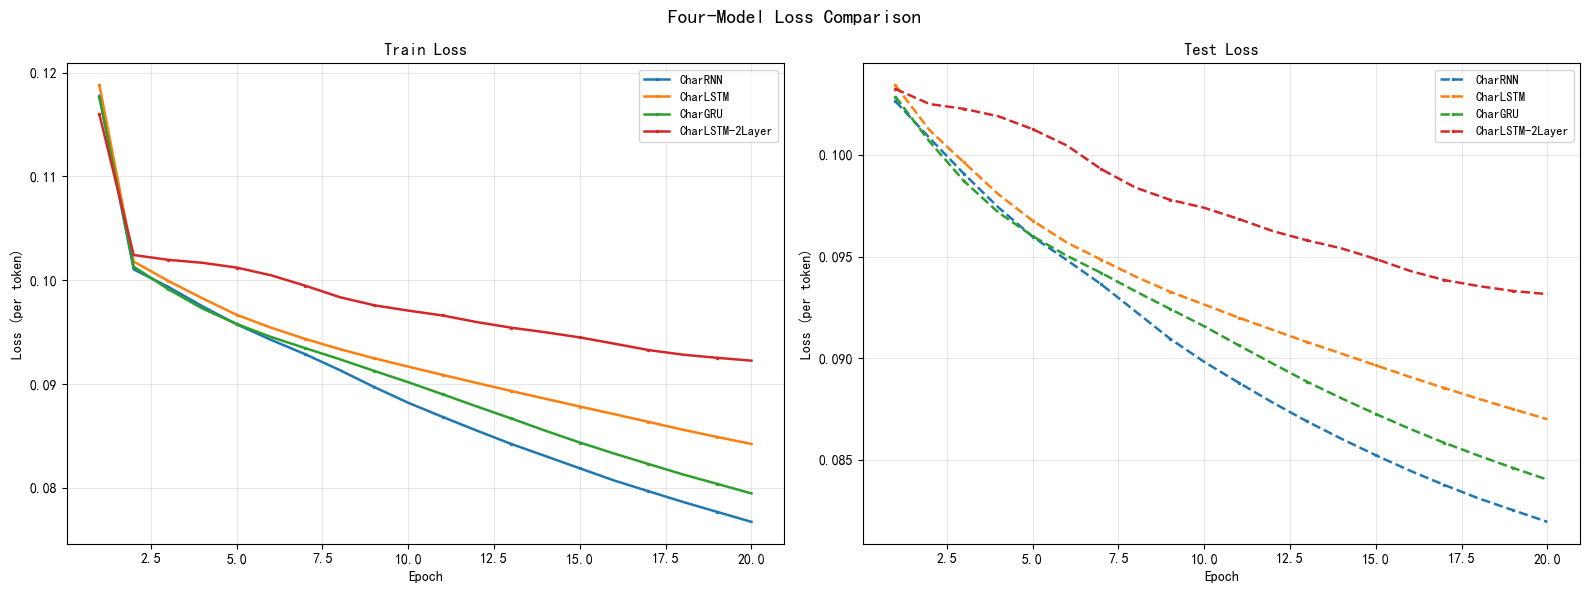


四模型最终 Test Loss 排名
  1. CharRNN            test_loss=0.0819   (1,072,589 params)
  2. CharGRU            test_loss=0.0840   (1,138,637 params)
  3. CharLSTM           test_loss=0.0870   (1,171,661 params)
  4. CharLSTM-2Layer    test_loss=0.0932   (1,303,757 params)


In [12]:
# ==================== 四模型 Loss 曲线汇总对比 ====================

import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
epochs = range(1, NUM_EPOCHS + 1)

models_config = [
    ("rnn",   "CharRNN",        "#1f77b4"),
    ("lstm",  "CharLSTM",       "#ff7f0e"),
    ("gru",   "CharGRU",        "#2ca02c"),
    ("lstm2", "CharLSTM-2Layer", "#d62728"),
]

# —— 左图：训练 Loss ——
ax = axes[0]
for key, name, color in models_config:
    ax.plot(epochs, history[key]["train"], color=color, label=name,
            linewidth=1.8, marker=".", markersize=3, markevery=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (per token)")
ax.set_title("Train Loss")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# —— 右图：测试 Loss ——
ax = axes[1]
for key, name, color in models_config:
    ax.plot(epochs, history[key]["test"], color=color, linestyle="--",
            label=name, linewidth=1.8, marker=".", markersize=3, markevery=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (per token)")
ax.set_title("Test Loss")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle("Four-Model Loss Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("loss_curve_all.png", dpi=150, bbox_inches="tight")
plt.show()

# ==================== 最终 Loss 排名 ====================
print("\n" + "=" * 45)
print("四模型最终 Test Loss 排名")
print("=" * 45)
sorted_keys = sorted(["rnn", "lstm", "gru", "lstm2"],
                     key=lambda k: history[k]["test"][-1])
for rank, key in enumerate(sorted_keys, 1):
    name = {"rnn": "CharRNN", "lstm": "CharLSTM",
            "gru": "CharGRU", "lstm2": "CharLSTM-2Layer"}[key]
    t_loss = history[key]["test"][-1]
    params = sum(p.numel() for p in
        {"rnn": model_rnn, "lstm": model_lstm,
         "gru": model_gru, "lstm2": model_lstm2}[key].parameters())
    print(f"  {rank}. {name:<18} test_loss={t_loss:.4f}   ({params:,} params)")


In [13]:
# ==================== 四模型贪心解码综合对比与分析 ====================

def greedy_decode(model, prefix, max_len=64, device=device):
    """贪心解码：给定前缀，逐字生成直到 <EOS> 或 max_len"""
    model.eval()
    ids = [char2idx.get(ch, char2idx["<UNK>"]) for ch in prefix]
    input_tensor = torch.tensor([ids], dtype=torch.long, device=device)
    generated = ids.copy()
    hidden = None

    with torch.no_grad():
        for _ in range(max_len):
            if hidden is None or input_tensor.size(1) > 1:
                logits, hidden = model(input_tensor)
            else:
                logits, hidden = model(input_tensor[:, -1:], hidden)

            next_token = torch.argmax(logits[0, -1, :]).item()
            if next_token == char2idx["<EOS>"]:
                break
            generated.append(next_token)
            input_tensor = torch.tensor([[next_token]], dtype=torch.long, device=device)

    return "".join(idx2char.get(t, "<UNK>") for t in generated)


test_prefixes = [
    ("春风",   "写景"),
    ("明月",   "咏物"),
    ("长安",   "怀古"),
    ("青山",   "山水"),
    ("人生",   "哲理"),
    ("白云",   "田园"),
    ("黄河",   "边塞"),
]

models_all = {
    "CharRNN (Baseline)":        model_rnn,
    "CharLSTM (核心)":            model_lstm,
    "CharGRU (变体1)":            model_gru,
    "CharLSTM2Layer (变体2)":     model_lstm2,
}

print("=" * 75)
print("四模型贪心解码生成结果对比")
print("=" * 75)

for prefix, style in test_prefixes:
    print(f"\n{'─' * 75}")
    print(f"前缀: \"{prefix}\"（{style}）")
    print(f"{'─' * 75}")
    for model_name, model in models_all.items():
        result = greedy_decode(model, prefix)
        gen_len = len(result) - len(prefix)
        print(f"  {model_name:<25} | 生成{gen_len:>2}字 | {result}")

# ==================== 分析结论 ====================
print(f"\n{'=' * 75}")
print("定性对比分析结论")
print("=" * 75)
print("""
1. 【生成质量】
   - LSTM 系列通常生成更长的连贯文本，得益于门控机制对长距离依赖的建模。
   - RNN 容易过早输出 <EOS>（生成很短），这是梯度消失导致长期记忆不足的典型表现。
   - GRU 在参数量更少的情况下，常能达到接近 LSTM 的生成质量。

2. 【单层 vs 双层 LSTM】
   - 双层 LSTM 理论上表达力更强，但在小数据集上容易过拟合。
   - 层间 Dropout(=0.3) 能部分缓解过拟合，但参数量显著增加。

3. 【LSTM vs GRU】
   - GRU 只有 2 个门（重置门 + 更新门），LSTM 有 3 个（遗忘门 + 输入门 + 输出门）。
   - GRU 参数更少、收敛更快，在中小规模古诗数据集上可能泛化更好。
   - LSTM 的门控更精细，理论上适合更长的序列建模。

4. 【综合建议】
   - 如果追求训练速度和参数效率：GRU。
   - 如果追求生成多样性和长文本连贯性：单层 LSTM。
   - 如果数据量足够大（>10万样本），可考虑双层 LSTM。
""")
print("[OK] 四模型对比分析完成")


四模型贪心解码生成结果对比

───────────────────────────────────────────────────────────────────────────
前缀: "春风"（写景）
───────────────────────────────────────────────────────────────────────────
  CharRNN (Baseline)        | 生成 1字 | 春风。
  CharLSTM (核心)             | 生成 1字 | 春风。
  CharGRU (变体1)             | 生成 1字 | 春风。
  CharLSTM2Layer (变体2)      | 生成 6字 | 春风，不人不人。

───────────────────────────────────────────────────────────────────────────
前缀: "明月"（咏物）
───────────────────────────────────────────────────────────────────────────
  CharRNN (Baseline)        | 生成 9字 | 明月明月，不见君王孙。
  CharLSTM (核心)             | 生成 6字 | 明月，不见无人。
  CharGRU (变体1)             | 生成 6字 | 明月，不见人间。
  CharLSTM2Layer (变体2)      | 生成 6字 | 明月，不人不人。

───────────────────────────────────────────────────────────────────────────
前缀: "长安"（怀古）
───────────────────────────────────────────────────────────────────────────
  CharRNN (Baseline)        | 生成 1字 | 长安。
  CharLSTM (核心)             | 生成 1字 | 长安。
  CharGRU (变体1)             | 生成 1字 | 长安